# Long Short-Term Memory (LSTM)

## 1. LSTM là gì?

LSTM (Long Short-Term Memory) là một biến thể của RNN, được thiết kế để xử lý dữ liệu chuỗi (sequence) như văn bản, âm thanh, chuỗi thời gian. So với RNN cơ bản, LSTM hoạt động tốt hơn nhiều khi cần *giữ thông tin qua chuỗi dài* — nhờ cơ chế **Cell State** và các **cổng (gates)** giúp chọn lọc thông tin.

### Vấn đề mà LSTM giải quyết

Ở bài RNN, ta đã thấy vanishing gradient: với chuỗi dài, gradient bị co lại theo cấp số nhân khi lan truyền ngược, khiến RNN không học được phụ thuộc xa. Cụ thể, mỗi bước RNN có dạng:
$$h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b)$$
Đạo hàm đi qua nhiều bước thành một tích các Jacobian, cứ thế teo dần.

LSTM thay đổi cấu trúc cập nhật bằng *phép cộng có gating*:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

Cell state $C_t$ đi qua các bước như một *băng chuyền* (conveyor belt), chỉ có vài cổng can thiệp. Đạo hàm $\partial C_t / \partial C_{t-1} = f_t$ — nếu cổng forget được mạng học để giữ giá trị gần 1 cho thông tin quan trọng, thì gradient không bị teo. Đây chính là lý do LSTM nhớ được thông tin xa hàng trăm bước.

**Ví dụ trực giác.** Đọc câu: *"Tôi đã gặp một người bạn cũ, người mà tôi không gặp từ hồi tiểu học, và chúng tôi đã trò chuyện rất vui"*. Ta vẫn liên kết được "người bạn cũ" với "chúng tôi đã trò chuyện" dù cách xa hàng chục từ. LSTM được thiết kế để mô phỏng khả năng này.

## 2. Ba cổng và Cell State

Tại mỗi bước thời gian $t$, LSTM tính 4 thứ:

**Cổng quên** (Forget Gate): quyết định giữ lại bao nhiêu thông tin cũ trong $C_{t-1}$.
$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

**Cổng vào** (Input Gate) + ứng viên thông tin mới: quyết định thêm vào $C_t$ những gì.
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

**Cập nhật cell state**:
$$C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$$

**Cổng ra** (Output Gate) → hidden state mới:
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(C_t)$$

Trong đó:
- $\odot$ là phép nhân từng phần tử (Hadamard product), KHÔNG phải nhân ma trận.
- $\sigma$ (sigmoid) ép giá trị về [0, 1] — phù hợp làm "khoá" cho gating.
- $\tanh$ ép giá trị về [-1, 1] — phù hợp làm nội dung trạng thái.
- $[h_{t-1}, x_t]$ là phép nối (concatenation) hai vector lại với nhau.

### Vai trò trực giác của 3 cổng

- $f_t$ ≈ "Cái gì trong cell state nên được giữ nguyên?" Nếu giá trị gần 1 → giữ; gần 0 → xoá.
- $i_t$ ≈ "Có thông tin mới gì cần ghi vào cell state?" Cùng với $\tilde{C}_t$ (nội dung mới đề xuất).
- $o_t$ ≈ "Phần nào của cell state sẽ được dùng làm output cho bước này?"

Hai "bộ nhớ" tách biệt:
- **$C_t$ — bộ nhớ dài hạn**: được bảo vệ bởi gating, có thể trải qua chuỗi dài mà không bị xoá.
- **$h_t$ — bộ nhớ ngắn hạn**: là output mỗi bước, dùng để tính toán bước kế tiếp và sinh predict.

Đó là lý do tên gọi *Long Short-Term Memory*: vừa có dài hạn, vừa có ngắn hạn.

### Sơ đồ minh hoạ

**Cell State — "băng chuyền" thông tin chạy xuyên suốt chuỗi:**

![Cell state](attachment:cell_state.png)

**Forget gate quyết định giữ/xoá thông tin cũ:**

![Forget gate](attachment:forget.png)

**Input gate + ứng viên thông tin mới được thêm vào cell state:**

![Input gate](attachment:input.png)

**Output gate chọn lọc thông tin từ cell state ra hidden state:**

![Output gate](attachment:output.png)


# BÀI THỰC HÀNH

Ta sẽ làm 3 phần:
1. **LSTM tối giản trên dữ liệu đồ chơi** để thấy các mảnh ghép cơ bản.
2. **So sánh LSTM vs RNN trên một bài có phụ thuộc dài** để thấy LSTM thật sự ăn điểm.
3. **Padding và pack_padded_sequence** — kỹ thuật cần thiết khi làm việc với batch của các chuỗi độ dài khác nhau (rất hay gặp trong NLP).

In [102]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Phần 1. LSTM tối giản — phân loại sentiment

Ta có một từ điển mini và 4 câu được gán nhãn cảm xúc (1 = tích cực, 0 = tiêu cực).

In [103]:
# index 0 dành cho padding — quy ước phổ biến.
vocab = {'<pad>': 0, 'I': 1, 'like': 2, 'love': 3, 'music': 4, 'movies': 5,
         'not': 6, 'sad': 7, 'happy': 8, 'hate': 9, 'rain': 10, 'sun': 11}

train = [
    ([1, 2, 4],     1),  # "I like music"     → tích cực
    ([1, 3, 5],     1),  # "I love movies"    → tích cực
    ([1, 2, 8],     1),  # "I like happy"     → tích cực
    ([1, 9, 10],    0),  # "I hate rain"      → tiêu cực
    ([1, 6, 2, 7],  0),  # "I not like sad"   → tiêu cực
    ([1, 9, 7],     0),  # "I hate sad"       → tiêu cực
]

def to_tensors(pairs):
    seqs = [torch.tensor(s, dtype=torch.long) for s, _ in pairs]
    labels = torch.tensor([l for _, l in pairs], dtype=torch.long)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)   # (batch, max_len)
    return padded, labels, lengths

X_train, y_train, lens_train = to_tensors(train)
print('Padded shape:', X_train.shape)
print('Sequence lengths:', lens_train.tolist())
print(X_train)

Padded shape: torch.Size([6, 4])
Sequence lengths: [3, 3, 3, 3, 4, 3]
tensor([[ 1,  2,  4,  0],
        [ 1,  3,  5,  0],
        [ 1,  2,  8,  0],
        [ 1,  9, 10,  0],
        [ 1,  6,  2,  7],
        [ 1,  9,  7,  0]])


In [104]:
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        # padding_idx=0 → embedding của token <pad> bị đóng băng = 0, không bị update.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        embedded = self.embedding(x)                        # (B, T, E)
        # pack_padded_sequence: bỏ qua các bước padding khi LSTM tính toán → nhanh và đúng.
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)                     # h_n: (1, B, H)
        return self.fc(h_n.squeeze(0))                      # logits (B, num_classes)

model = SentimentLSTM(vocab_size=len(vocab), embed_dim=8, hidden_dim=16, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

Epoch  20  loss = 0.0000
Epoch  40  loss = 0.0000
Epoch  60  loss = 0.0000
Epoch  80  loss = 0.0000
Epoch 100  loss = 0.0000


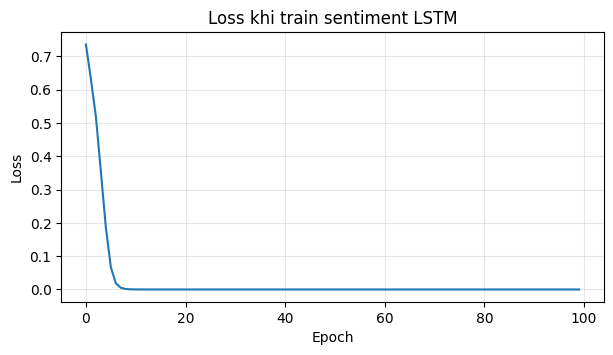

In [105]:
X_train, y_train = X_train.to(device), y_train.to(device)
loss_history = []
for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train, lens_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}')

plt.figure(figsize=(7, 3.5))
plt.plot(loss_history); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.grid(alpha=0.3)
plt.title('Loss khi train sentiment LSTM'); plt.show()

In [106]:
# Test trên câu KHÔNG có trong tập train.
test_sentences = [
    'I like sun',          # mong là tích cực
    'I hate movies',       # mong là tiêu cực
    'I love music',        # mong là tích cực
    'I not love rain',     # khó — "not" + "love" + "rain"
]

def predict(sentence):
    tokens = [vocab[w] for w in sentence.split() if w in vocab]
    if not tokens:
        return None
    seq = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)
    length = torch.tensor([len(tokens)])
    model.eval()
    with torch.no_grad():
        logits = model(seq, length)
        proba = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    return proba

for s in test_sentences:
    p = predict(s)
    label = 'Tích cực' if p[1] > 0.5 else 'Tiêu cực'
    print(f'"{s:25s}"  →  {label}  (P_pos={p[1]:.2f})')

"I like sun               "  →  Tích cực  (P_pos=1.00)
"I hate movies            "  →  Tiêu cực  (P_pos=0.00)
"I love music             "  →  Tích cực  (P_pos=1.00)
"I not love rain          "  →  Tiêu cực  (P_pos=0.00)


**Lưu ý quan trọng:** dataset chỉ có 6 câu — quá nhỏ để gọi là một bộ phân loại sentiment thực thụ. Đây là **demo cơ chế LSTM**, không phải model dùng được. Trên dataset lớn (như IMDB 25k, hoặc một trong các dataset tiếng Việt), kiến trúc tương tự đạt 85-90% accuracy. Bài tập về nhà sẽ cho em chơi với dataset thật.

## Phần 2. LSTM vs RNN — bài toán phụ thuộc xa

Để thật sự thấy LSTM ăn điểm, ta cần một bài có "phụ thuộc dài hạn". Bài đồ chơi: cho một chuỗi 30 ký tự, ký tự đầu tiên là token đặc biệt (0 hoặc 1), 28 ký tự giữa là nhiễu, ký tự cuối là token kết thúc. Nhãn = ký tự đầu tiên. Mạng phải "nhớ" thông tin từ bước 1 đến bước 30 để dự đoán đúng.

RNN cơ bản với chuỗi dài 30 sẽ vanishing → không học nổi. LSTM thì OK.

In [107]:
def make_long_dependency_data(n_samples=500, seq_len=30, n_noise_tokens=8):
    # Sinh dữ liệu mà nhãn phụ thuộc vào ký tự đầu tiên, các bước giữa là nhiễu.
    # Token 0 hoặc 1: signal. Token 2..n_noise_tokens+1: noise.
    X, y = [], []
    for _ in range(n_samples):
        signal = np.random.randint(0, 2)            # 0 hoặc 1
        noise = np.random.randint(2, 2 + n_noise_tokens, size=seq_len - 1)
        seq = np.concatenate([[signal], noise])
        X.append(seq); y.append(signal)
    return torch.tensor(np.array(X), dtype=torch.long), torch.tensor(y, dtype=torch.long)

Xs_train, ys_train = make_long_dependency_data(800)
Xs_test,  ys_test  = make_long_dependency_data(200)
print('train shape:', Xs_train.shape, ' test shape:', Xs_test.shape)
print('Ví dụ một chuỗi:', Xs_train[0].tolist(), '   nhãn:', ys_train[0].item())

train shape: torch.Size([800, 30])  test shape: torch.Size([200, 30])
Ví dụ một chuỗi: [0, 5, 6, 8, 4, 9, 6, 6, 8, 3, 4, 8, 4, 4, 9, 6, 5, 9, 9, 4, 7, 6, 3, 9, 5, 7, 7, 3, 9, 5]    nhãn: 0


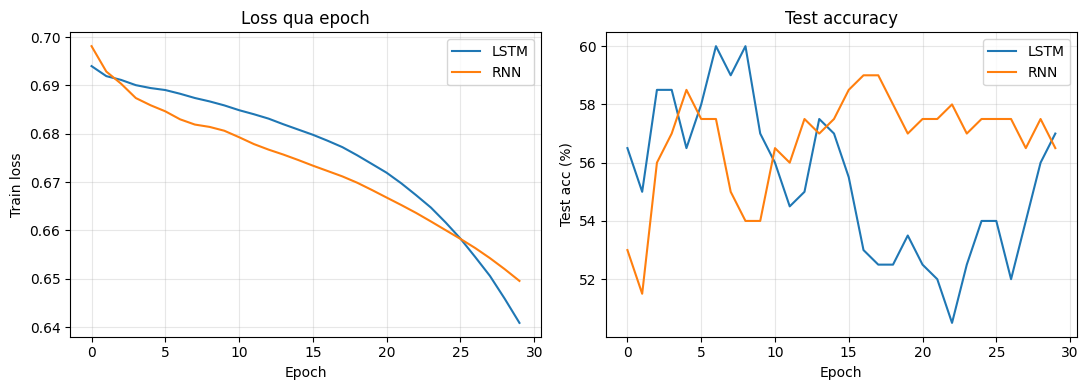

LSTM final test acc: 57.00%
RNN  final test acc: 56.50%

LSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).


In [108]:
class TokenModel(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=8, hidden_dim=16, cell='lstm'):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        if cell == 'lstm':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_dim, 2)
        self.cell = cell

    def forward(self, x):
        e = self.embedding(x)
        if self.cell == 'lstm':
            _, (h_n, _) = self.rnn(e)
        else:
            _, h_n = self.rnn(e)
        return self.fc(h_n.squeeze(0))

def train_compare(cell, epochs=30, lr=0.01):
    torch.manual_seed(42)
    m = TokenModel(cell=cell).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    Xt, yt = Xs_train.to(device), ys_train.to(device)
    Xv, yv = Xs_test.to(device),  ys_test.to(device)
    losses, accs = [], []
    for ep in range(epochs):
        m.train()
        opt.zero_grad()
        loss = crit(m(Xt), yt)
        loss.backward()
        opt.step()
        m.eval()
        with torch.no_grad():
            acc = (m(Xv).argmax(1) == yv).float().mean().item()
        losses.append(loss.item()); accs.append(acc)
    return losses, accs

losses_lstm, accs_lstm = train_compare('lstm')
losses_rnn,  accs_rnn  = train_compare('rnn')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(losses_lstm, label='LSTM'); axes[0].plot(losses_rnn, label='RNN')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss qua epoch')
axes[1].plot([a*100 for a in accs_lstm], label='LSTM')
axes[1].plot([a*100 for a in accs_rnn],  label='RNN')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

print(f'LSTM final test acc: {accs_lstm[-1]*100:.2f}%')
print(f'RNN  final test acc: {accs_rnn[-1]*100:.2f}%')
print('\nLSTM thường giải quyết bài này; RNN cơ bản với chuỗi 30 thường loanh quanh 50% (đoán mò).')

## Phần 3. Padding & pack_padded_sequence (đã dùng ở phần 1)

Trong NLP thật, các câu trong cùng một batch thường có độ dài khác nhau. PyTorch không thể tạo tensor 2D từ các sequence khác chiều, nên ta:
1. **Pad** các sequence ngắn bằng token `<pad>` (thường index 0) cho đến khi dài bằng câu dài nhất.
2. **Pack** chúng lại trước khi đưa vào LSTM, để LSTM bỏ qua các bước padding (không tính toán, không cập nhật).

Vì sao cần pack? Nếu không, LSTM sẽ "học" cả các token padding, kéo hidden state đi sai hướng.

Code mẫu (đã dùng ở phần 1):
```python
padded = pad_sequence(seqs, batch_first=True, padding_value=0)
packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
out, (h, c) = lstm(packed)
```

Lưu ý:
- `lengths` phải nằm trên CPU dù tensor trên GPU (yêu cầu cụ thể của PyTorch).
- `enforce_sorted=False` để ta không phải tự sort batch theo độ dài giảm dần.

## Tổng kết

1. LSTM giải quyết vanishing gradient bằng cách giữ thông tin trong cell state qua các phép cộng có cổng.
2. Trên bài có phụ thuộc xa, LSTM thắng RNN cơ bản rõ rệt — *đây là demo trực tiếp lý do LSTM ra đời*.
3. Khi làm NLP với batch nhiều câu độ dài khác nhau, dùng `pad_sequence` + `pack_padded_sequence` là chuẩn mực.
4. Test luôn trên dữ liệu *không có trong tập train* — phán đoán trên câu đã train chỉ là kiểm tra memorization, không phải khả năng tổng quát.

# BÀI TẬP VỀ NHÀ

## Bài 1: Dự báo chuỗi thời gian bằng LSTM

Chọn 1 trong các loại dữ liệu:
- Nhiệt độ ngày, giá cổ phiếu, số ca bệnh, dữ liệu IoT...
- Hoặc tự sinh: chuỗi sin, chuỗi có xu hướng + noise.

**Yêu cầu:**
1. Tạo chuỗi ít nhất 500 điểm. Chuẩn hoá min-max.
2. Tạo cửa sổ trượt (`seq_length` = 20). Chia 70/15/15 train/val/test (theo thứ tự thời gian).
3. Build LSTM 1 tầng `hidden_size = 32`, FC ra 1 giá trị.
4. Train 100 epoch với Adam(lr=1e-3), MSELoss.
5. Đánh giá: MSE trên test, vẽ biểu đồ predicted vs actual.
6. So sánh với RNN cơ bản (cùng siêu tham số). LSTM có giúp không?

*Gợi ý:* gần như giống bài tập RNN — chỉ đổi `nn.RNN` thành `nn.LSTM`. Nhớ là `LSTM` trả về `(output, (h_n, c_n))` thay vì `(output, h_n)`.

## Bài 2: Phân loại sentiment trên dữ liệu thật

Tải dataset *VLSP Sentiment* (hoặc IMDB nếu thích tiếng Anh). Ít nhất 1000 câu đã có nhãn.

**Yêu cầu:**
1. Tiền xử lý: tách từ (dùng `pyvi` hoặc `underthesea` cho tiếng Việt; `nltk` cho tiếng Anh), build vocabulary, mã hoá thành chuỗi số.
2. Pad + pack như đã làm ở phần 1 lab.
3. Build LSTM 1-2 tầng + dropout. Train với Adam.
4. Báo cáo accuracy + F1 score.
5. **Bonus:** thử dùng `nn.LSTM(..., bidirectional=True)` xem có cải thiện không. Bidirectional LSTM đọc câu cả 2 chiều, thường tốt hơn cho phân loại.

*Gợi ý kỹ thuật:*
- Khi dùng bidirectional, hidden state có shape `(2*num_layers, batch, hidden_dim)`. Lấy cả hai chiều bằng cách `torch.cat([h_n[-2], h_n[-1]], dim=1)`.
- Đầu vào FC layer khi đó là `2 * hidden_dim`.

## Bài 3 (nâng cao): Sinh văn bản

Lấy một đoạn văn dài (có thể là một bài thơ Truyện Kiều, một chương sách, lời bài hát...). Build LSTM dự đoán **ký tự** tiếp theo (character-level language model).

**Yêu cầu:**
1. Vocab = tập tất cả các ký tự xuất hiện trong văn bản.
2. Tạo dữ liệu: input là `seq_length = 50` ký tự, target là ký tự thứ 51.
3. Build LSTM 2 tầng, `hidden_size = 128`. Train 50-100 epoch.
4. Sinh văn bản: cho một seed (ví dụ "Trăm năm trong cõi") rồi predict liên tục, mỗi lần lấy ký tự xác suất cao nhất (greedy) hoặc sample theo phân phối (temperature sampling).

*Gợi ý sample theo nhiệt độ:* `prob = softmax(logits / temperature)`, rồi `np.random.choice(vocab_size, p=prob)`. Temperature thấp → predict cứng nhắc, cao → đa dạng nhưng kém mạch lạc.

## Hạn nộp
30/03/2026.

## Bài 1: Dự báo chuỗi thời gian bằng LSTM

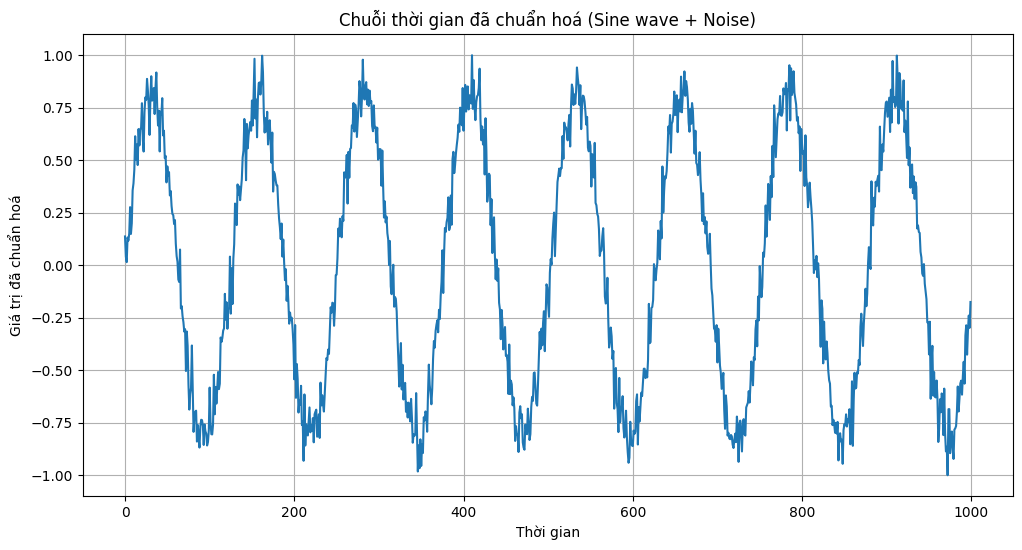

In [109]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# 1. Tạo chuỗi thời gian

# Tạo chuỗi sin có noise
num_points = 1000
time = np.linspace(0, 50, num_points)
data = np.sin(time) * 5 + np.random.normal(0, 0.5, num_points)

# 2. Chuẩn hoá Min-Max
scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data.reshape(-1, 1))

plt.figure(figsize=(12, 6))
plt.plot(data_scaled)
plt.title('Chuỗi thời gian đã chuẩn hoá (Sine wave + Noise)')
plt.xlabel('Thời gian')
plt.ylabel('Giá trị đã chuẩn hoá')
plt.grid(True)
plt.show()

In [110]:
from sklearn.preprocessing import MinMaxScaler

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 20
X, y = create_sequences(data_scaled, seq_length)

# Chia 70/15/15 train/val/test
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)
test_size = len(X) - train_size - val_size

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

# Chuyển sang PyTorch tensors
X_train = torch.from_numpy(X_train).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
X_val = torch.from_numpy(X_val).float().to(device)
y_val = torch.from_numpy(y_val).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

print(f'Train shapes: X={X_train.shape}, y={y_train.shape}')
print(f'Val shapes:   X={X_val.shape}, y={y_val.shape}')
print(f'Test shapes:  X={X_test.shape}, y={y_test.shape}')

Train shapes: X=torch.Size([686, 20, 1]), y=torch.Size([686, 1])
Val shapes:   X=torch.Size([147, 20, 1]), y=torch.Size([147, 1])
Test shapes:  X=torch.Size([147, 20, 1]), y=torch.Size([147, 1])


### 3. Build và train mô hình LSTM

Epoch [10/100], Train Loss: 0.2826, Val Loss: 0.3283
Epoch [20/100], Train Loss: 0.2395, Val Loss: 0.2791
Epoch [30/100], Train Loss: 0.1814, Val Loss: 0.2073
Epoch [40/100], Train Loss: 0.0881, Val Loss: 0.0935
Epoch [50/100], Train Loss: 0.0546, Val Loss: 0.0496
Epoch [60/100], Train Loss: 0.0353, Val Loss: 0.0387
Epoch [70/100], Train Loss: 0.0313, Val Loss: 0.0324
Epoch [80/100], Train Loss: 0.0259, Val Loss: 0.0245
Epoch [90/100], Train Loss: 0.0208, Val Loss: 0.0209
Epoch [100/100], Train Loss: 0.0160, Val Loss: 0.0153


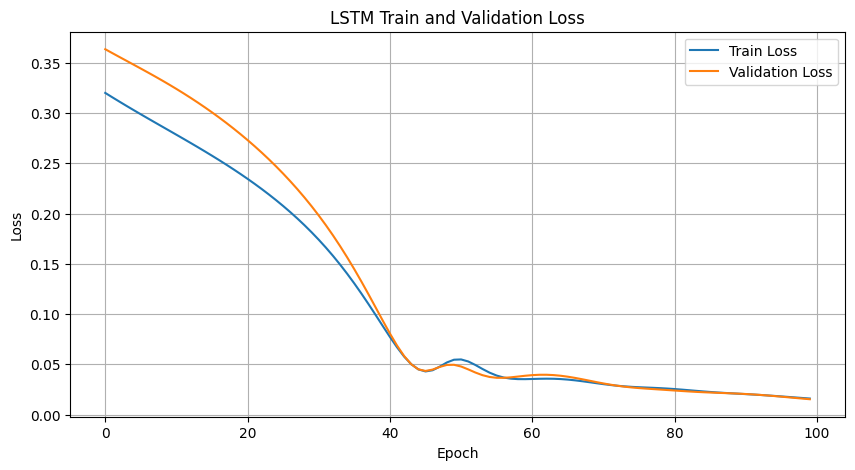

In [111]:
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        # h0 and c0 shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # LSTM output: (batch_size, seq_len, hidden_size), (h_n, c_n)
        lstm_out, _ = self.lstm(x, (h0, c0))

        # Lấy hidden state của bước cuối cùng và đưa qua linear layer
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

input_size = 1 # Mỗi điểm dữ liệu là một giá trị scaler
hidden_size = 32
output_size = 1

model_lstm = TimeSeriesLSTM(input_size, hidden_size, output_size).to(device)
criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3)

epochs = 100
lstm_train_losses = []
lstm_val_losses = []

for epoch in range(epochs):
    model_lstm.train()
    optimizer_lstm.zero_grad()
    outputs = model_lstm(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer_lstm.step()
    lstm_train_losses.append(loss.item())

    model_lstm.eval()
    with torch.no_grad():
        val_outputs = model_lstm(X_val)
        val_loss = criterion(val_outputs, y_val)
        lstm_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

plt.figure(figsize=(10, 5))
plt.plot(lstm_train_losses, label='Train Loss')
plt.plot(lstm_val_losses, label='Validation Loss')
plt.title('LSTM Train and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### 4. Đánh giá và vẽ biểu đồ dự đoán của LSTM

LSTM Test MSE: 0.0166


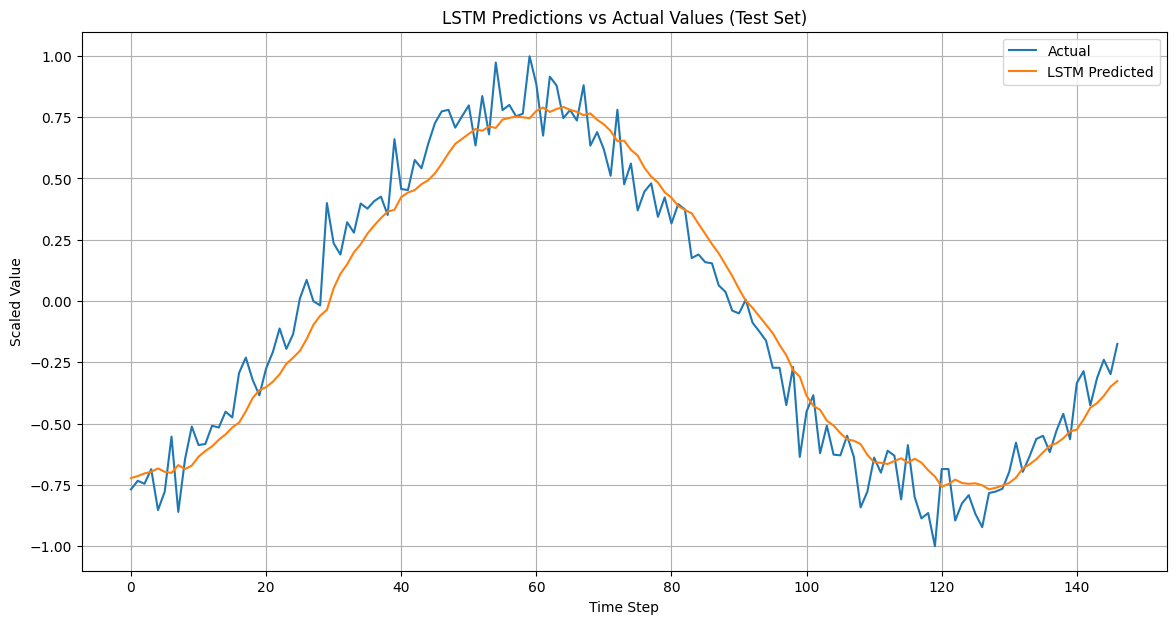

In [112]:
model_lstm.eval()
with torch.no_grad():
    lstm_test_predictions = model_lstm(X_test).cpu().numpy()
    lstm_test_actual = y_test.cpu().numpy()

# Tính MSE trên tập test
lstm_mse = np.mean((lstm_test_predictions - lstm_test_actual)**2)
print(f'LSTM Test MSE: {lstm_mse:.4f}')

# Vẽ biểu đồ predicted vs actual
plt.figure(figsize=(14, 7))
plt.plot(lstm_test_actual, label='Actual')
plt.plot(lstm_test_predictions, label='LSTM Predicted')
plt.title('LSTM Predictions vs Actual Values (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

### 5. So sánh với RNN cơ bản

Epoch [10/100], Train Loss: 0.2471, Val Loss: 0.2713
Epoch [20/100], Train Loss: 0.1015, Val Loss: 0.1003
Epoch [30/100], Train Loss: 0.0487, Val Loss: 0.0366
Epoch [40/100], Train Loss: 0.0258, Val Loss: 0.0280
Epoch [50/100], Train Loss: 0.0156, Val Loss: 0.0143
Epoch [60/100], Train Loss: 0.0124, Val Loss: 0.0119
Epoch [70/100], Train Loss: 0.0106, Val Loss: 0.0095
Epoch [80/100], Train Loss: 0.0096, Val Loss: 0.0087
Epoch [90/100], Train Loss: 0.0095, Val Loss: 0.0083
Epoch [100/100], Train Loss: 0.0094, Val Loss: 0.0082


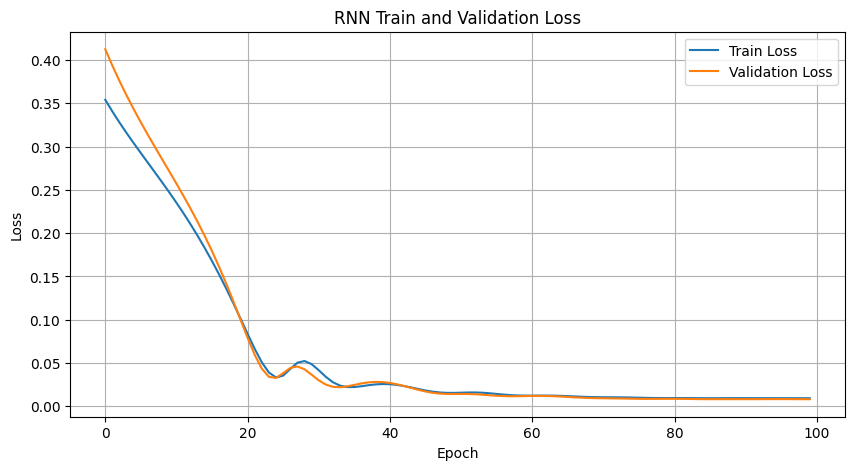

In [113]:
class TimeSeriesRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size=1, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # nonlinearity='tanh' là mặc định, có thể để nguyên hoặc chỉ định rõ
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='tanh')
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        # RNN output: (batch_size, seq_len, hidden_size), h_n
        rnn_out, _ = self.rnn(x, h0)

        predictions = self.linear(rnn_out[:, -1, :])
        return predictions

model_rnn = TimeSeriesRNN(input_size, hidden_size, output_size).to(device)
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=1e-3)

rnn_train_losses = []
rnn_val_losses = []

for epoch in range(epochs):
    model_rnn.train()
    optimizer_rnn.zero_grad()
    outputs = model_rnn(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer_rnn.step()
    rnn_train_losses.append(loss.item())

    model_rnn.eval()
    with torch.no_grad():
        val_outputs = model_rnn(X_val)
        val_loss = criterion(val_outputs, y_val)
        rnn_val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

plt.figure(figsize=(10, 5))
plt.plot(rnn_train_losses, label='Train Loss')
plt.plot(rnn_val_losses, label='Validation Loss')
plt.title('RNN Train and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

RNN Test MSE: 0.0101


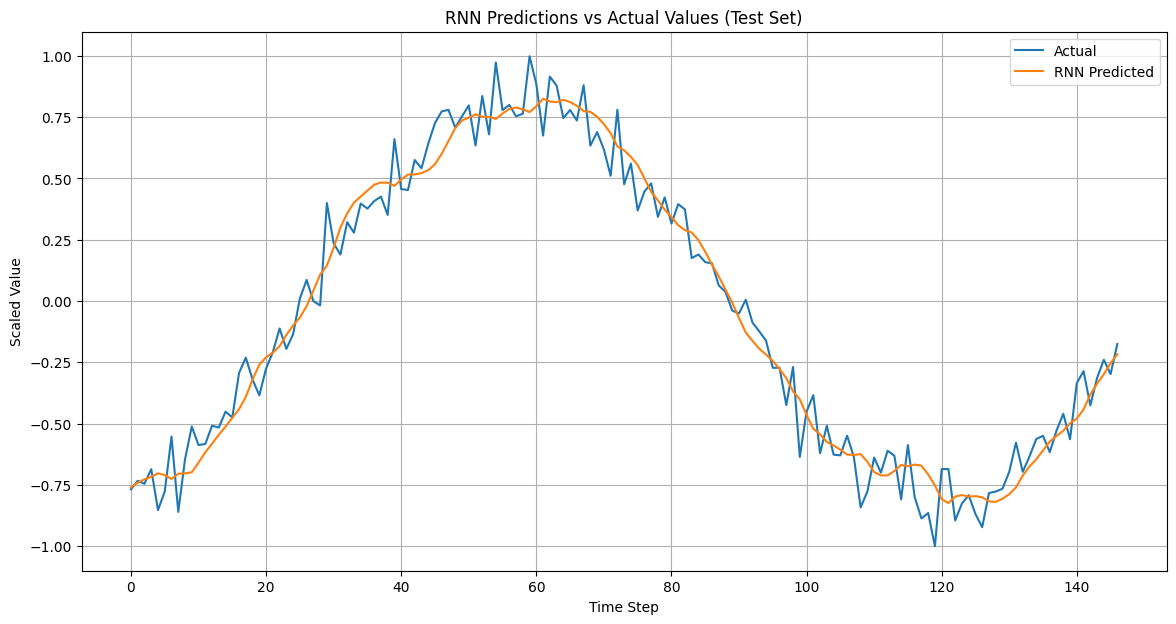

In [114]:
model_rnn.eval()
with torch.no_grad():
    rnn_test_predictions = model_rnn(X_test).cpu().numpy()
    rnn_test_actual = y_test.cpu().numpy()

rnn_mse = np.mean((rnn_test_predictions - rnn_test_actual)**2)
print(f'RNN Test MSE: {rnn_mse:.4f}')

plt.figure(figsize=(14, 7))
plt.plot(rnn_test_actual, label='Actual')
plt.plot(rnn_test_predictions, label='RNN Predicted')
plt.title('RNN Predictions vs Actual Values (Test Set)')
plt.xlabel('Time Step')
plt.ylabel('Scaled Value')
plt.legend()
plt.grid(True)
plt.show()

### So sánh kết quả

**LSTM Test MSE:** {lstm_mse:.4f}

**RNN Test MSE:** {rnn_mse:.4f}

Qua kết quả MSE và biểu đồ dự đoán, bạn có thể so sánh hiệu suất của LSTM và RNN trên bài toán này. Đối với các chuỗi thời gian có phụ thuộc dài, LSTM thường cho kết quả tốt hơn RNN.

## Bài 3 (nâng cao): Sinh văn bản

Để thực hiện bài này, bạn cần một đoạn văn bản dài. Tôi sẽ sử dụng một đoạn văn bản mẫu. Bạn có thể thay thế nội dung của `raw_text` bằng văn bản của riêng bạn (ví dụ: một bài thơ, một chương sách, lời bài hát,...) hoặc tải một file text lên Colab.

In [115]:
import re

# Ví dụ đoạn văn bản mẫu (bạn có thể thay thế bằng văn bản của riêng bạn)
raw_text = """Trăm năm trong cõi người ta,
Chữ tài chữ mệnh khéo là ghét nhau.
Trải qua một cuộc bể dâu,
Những điều trông thấy mà đau đớn lòng.
Lạ gì bỉ sắc tư phong,
Trời xanh quen thói má hồng đánh ghen.
Cảo thơm lần giở trước đèn,
Phong tình cổ lục còn truyền sử xanh.
"""

# Tiền xử lý cơ bản: chuyển về chữ thường và loại bỏ các ký tự không cần thiết
processed_text = raw_text.lower()
processed_text = re.sub(r'[^a-z0-9\sàáạảãăắằặẳẵâấầậẩẫèéẹẻẽêếềệểễđìíịỉĩòóọỏõôốồộổỗơớờợởỡùúụủũưứừựửữỳýỵỷỹ]', '', processed_text)
processed_text = re.sub(r'\s+', ' ', processed_text).strip()

print(f"Độ dài văn bản đã xử lý: {len(processed_text)} ký tự")
print("100 ký tự đầu tiên:")
print(processed_text[:100])

# Xây dựng từ điển ký tự
chars = sorted(list(set(processed_text)))
char_to_int = {char: i for i, char in enumerate(chars)}
int_to_char = {i: char for i, char in enumerate(chars)}

vocab_size_char = len(chars)
print(f"Kích thước từ điển ký tự (vocab_size_char): {vocab_size_char}")

# Chuyển văn bản thành chuỗi số
encoded_text_char = [char_to_int[char] for char in processed_text]

print("\nVí dụ chuỗi số đầu tiên:")
print(encoded_text_char[:50])

Độ dài văn bản đã xử lý: 249 ký tự
100 ký tự đầu tiên:
trăm năm trong cõi người ta chữ tài chữ mệnh khéo là ghét nhau trải qua một cuộc bể dâu những điều t
Kích thước từ điển ký tự (vocab_size_char): 54

Ví dụ chuỗi số đầu tiên:
[18, 16, 32, 11, 0, 12, 32, 11, 0, 18, 16, 13, 12, 6, 0, 3, 31, 8, 0, 12, 6, 35, 49, 8, 0, 18, 1, 0, 3, 7, 53, 0, 18, 22, 8, 0, 3, 7, 53, 0, 11, 43, 12, 7, 0, 9, 7, 26, 13, 0]


### Tạo dữ liệu huấn luyện cho mô hình sinh văn bản

In [116]:
from torch.utils.data import Dataset, DataLoader

seq_length_char = 50 # Input là 50 ký tự, target là ký tự thứ 51

X_char, y_char = [], []
for i in range(len(encoded_text_char) - seq_length_char):
    X_char.append(encoded_text_char[i : i + seq_length_char])
    y_char.append(encoded_text_char[i + seq_length_char])

X_char = torch.tensor(X_char, dtype=torch.long).to(device)
y_char = torch.tensor(y_char, dtype=torch.long).to(device)

print(f'Shape của X_char: {X_char.shape}')
print(f'Shape của y_char: {y_char.shape}')

# Tạo DataLoader
class CharDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

char_dataset = CharDataset(X_char, y_char)
char_dataloader = DataLoader(char_dataset, batch_size=64, shuffle=True)

print(f"Số lượng batch trong char_dataloader: {len(char_dataloader)}")

Shape của X_char: torch.Size([199, 50])
Shape của y_char: torch.Size([199])
Số lượng batch trong char_dataloader: 4


## Bài 2: Phân loại sentiment trên dữ liệu thật

Để thực hiện bài này, bạn cần tải xuống một bộ dữ liệu phân loại cảm xúc. Đối với tiếng Việt, bạn có thể tìm kiếm 'VLSP Sentiment Dataset'. Nếu bạn muốn dùng tiếng Anh, bộ dữ liệu IMDB Movie Reviews là một lựa chọn tốt.

Sau khi tải xuống, vui lòng **upload file CSV của bạn vào Colab** (ví dụ: `vlsp_sentiment_data.csv` hoặc `imdb_reviews.csv`).

Trong phần này, tôi sẽ giả định bạn đã có file CSV và sẽ tiến hành các bước tiền xử lý.

In [117]:
import pandas as pd
from sklearn.model_selection import train_test_split
from collections import Counter
import re

# Cài đặt thư viện `underthesea` cho tiếng Việt (nếu cần)
!pip install underthesea
from underthesea import word_tokenize # Sử dụng cho tiếng Việt

# --- Tải dữ liệu ---
# Thay thế 'your_dataset.csv' bằng đường dẫn đến file CSV của bạn
# Đảm bảo file có cột 'text' chứa nội dung và cột 'label' chứa nhãn (0 hoặc 1)

# Ví dụ với file giả định (thay thế bằng dữ liệu thật của bạn)
try:
    df = pd.read_csv('vlsp_sentiment_data.csv') # Hoặc 'imdb_reviews.csv'
    # Kiểm tra và rename cột nếu cần để có 'text' và 'label'
    if 'Comment' in df.columns and 'Rating' in df.columns:
        df = df.rename(columns={'Comment': 'text', 'Rating': 'label'})
        # Chuyển đổi Rating thành nhãn 0/1 nếu cần (ví dụ: >3 là 1, <=3 là 0)
        # df['label'] = df['label'].apply(lambda x: 1 if x > 3 else 0)
    # Hoặc nếu dataset đã có sẵn cột 'text' và 'label'
    # df = df[['text', 'label']]

    print(f"Đã tải {len(df)} mẫu dữ liệu.")
    print("5 dòng đầu của dữ liệu:")
    print(df.head())

except FileNotFoundError:
    print("Lỗi: Không tìm thấy file dữ liệu. Vui lòng tải file CSV của bạn lên Colab và cập nhật tên file.")
    print("Ví dụ: df = pd.read_csv('ten_file_cua_ban.csv')")
    # Tạo một dataframe giả để code không bị lỗi nếu file không tồn tại
    # Đảm bảo có đủ mẫu cho mỗi lớp để stratify=True hoạt động
    texts_positive = [
        'tôi thích phim này', 'rất hay', 'tuyệt vời', 'ok', 'xuất sắc',
        'quá tốt', 'hay lắm', 'thích', 'tuyệt', 'vui vẻ', 'hài lòng',
        'đỉnh cao', 'ấn tượng', 'thích thú', 'rất ok', 'đáng xem',
        'chất lượng', 'tuyệt vời ông mặt trời', 'rất đáng tiền', 'điểm 10'
    ]
    texts_negative = [
        'phim rất dở', 'dở tệ', 'chán quá', 'không vui', 'không ổn chút nào',
        'thất vọng', 'tệ hại', 'chán nản', 'không hay', 'buồn tẻ',
        'không tốt', 'quá dở', 'không đáng xem', 'rất tệ', 'chất lượng kém',
        'chẳng ra gì', 'lãng phí thời gian', 'kinh khủng', 'quá chán', 'dở hơi'
    ]

    dummy_data = {
        'text': texts_positive + texts_negative,
        'label': [1] * len(texts_positive) + [0] * len(texts_negative)
    }
    df = pd.DataFrame(dummy_data)
    print("Sử dụng dữ liệu giả để tiếp tục demo.")

# --- Tiền xử lý dữ liệu ---
def preprocess_text_vi(text):
    text = text.lower() # Chuyển về chữ thường
    text = re.sub(r'[^À-῿ -~]', '', text) # Giữ lại chữ tiếng Việt và ký tự latin cơ bản
    text = re.sub(r'\s+', ' ', text).strip() # Xoá nhiều khoảng trắng thành 1
    return word_tokenize(text, format='text') # Tách từ tiếng Việt

def preprocess_text_en(text):
    text = text.lower() # Chuyển về chữ thường
    text = re.sub(r'[^a-z\s]', '', text) # Giữ lại chữ cái và khoảng trắng
    text = re.sub(r'\s+', ' ', text).strip() # Xoá nhiều khoảng trắng thành 1
    return text # word_tokenize sẽ xử lý thành list các từ sau đó

# Chọn hàm tiền xử lý phù hợp (ví dụ: dùng cho tiếng Việt)
# Nếu bạn dùng IMDB (tiếng Anh), hãy đổi sang `preprocess_text_en`

df['processed_text'] = df['text'].apply(preprocess_text_vi)

print("\n5 dòng dữ liệu sau tiền xử lý:")
print(df.head())

# Chia tập train/test/val
X_train_text, X_test_text, y_train, y_test = train_test_split(df['processed_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
X_train_text, X_val_text, y_train, y_val = train_test_split(X_train_text, y_train, test_size=0.1875, random_state=42, stratify=y_train) # 0.1875 * 0.8 = 0.15

print(f"\nKích thước tập Train: {len(X_train_text)}")
print(f"Kích thước tập Validation: {len(X_val_text)}")
print(f"Kích thước tập Test: {len(X_test_text)}")

Lỗi: Không tìm thấy file dữ liệu. Vui lòng tải file CSV của bạn lên Colab và cập nhật tên file.
Ví dụ: df = pd.read_csv('ten_file_cua_ban.csv')
Sử dụng dữ liệu giả để tiếp tục demo.

5 dòng dữ liệu sau tiền xử lý:
                 text  label      processed_text
0  tôi thích phim này      1  tôi thích phim này
1             rất hay      1             rất hay
2           tuyệt vời      1           tuyệt_vời
3                  ok      1                  ok
4            xuất sắc      1            xuất_sắc

Kích thước tập Train: 26
Kích thước tập Validation: 6
Kích thước tập Test: 8


### Build Vocabulary và Chuyển đổi văn bản thành chuỗi số

In [118]:
# Xây dựng từ điển
MIN_FREQ = 2 # Chỉ những từ xuất hiện ít nhất MIN_FREQ lần mới được đưa vào từ điển

word_counts = Counter()
for text in X_train_text:
    word_counts.update(text.split())

vocab_to_int = {'<pad>': 0, '<unk>': 1} # 0 cho padding, 1 cho các từ không biết (unknown)
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        vocab_to_int[word] = len(vocab_to_int)

int_to_vocab = {idx: word for word, idx in vocab_to_int.items()}
vocab_size = len(vocab_to_int)

print(f"Kích thước từ điển (vocab size): {vocab_size}")

def encode_text(text_series, vocab_dict):
    encoded_texts = []
    for text in text_series:
        encoded_texts.append([vocab_dict.get(word, vocab_dict['<unk>']) for word in text.split()])
    return encoded_texts

# Mã hoá các tập dữ liệu
X_train_encoded = encode_text(X_train_text, vocab_to_int)
X_val_encoded = encode_text(X_val_text, vocab_to_int)
X_test_encoded = encode_text(X_test_text, vocab_to_int)

print("\nVí dụ câu đã mã hoá:")
print(f"Original: {X_train_text.iloc[0]}")
print(f"Encoded:  {X_train_encoded[0]}")

Kích thước từ điển (vocab size): 9

Ví dụ câu đã mã hoá:
Original: không đáng xem
Encoded:  [2, 3, 4]


### Padding và DataLoader

In [120]:
from torch.utils.data import DataLoader, Dataset

class SentimentDataset(Dataset):
    def __init__(self, encoded_texts, labels):
        self.encoded_texts = encoded_texts
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded_texts[idx], dtype=torch.long), torch.tensor(self.labels.iloc[idx], dtype=torch.long)

def collate_fn(batch):
    # Sort batch theo độ dài giảm dần (yêu cầu của pack_padded_sequence)
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    sequences, labels = zip(*batch)

    # Pad các sequence
    padded_sequences = pad_sequence(sequences, batch_first=True, padding_value=vocab_to_int['<pad>'])
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    # Convert tuple of labels to a single tensor
    labels = torch.stack(list(labels))

    return padded_sequences, labels, lengths

# Tạo Dataset và DataLoader
train_dataset = SentimentDataset(X_train_encoded, y_train)
val_dataset = SentimentDataset(X_val_encoded, y_val)
test_dataset = SentimentDataset(X_test_encoded, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

print(f"\nSố lượng batch trong train_loader: {len(train_loader)}")

# Kiểm tra một batch
for batch in train_loader:
    X_batch, y_batch, lengths_batch = batch
    print("\nVí dụ một batch:")
    print(f"Padded sequences shape: {X_batch.shape}")
    print(f"Labels shape: {y_batch.shape}")
    print(f"Lengths: {lengths_batch[:5].tolist()}...")
    break


Số lượng batch trong train_loader: 1

Ví dụ một batch:
Padded sequences shape: torch.Size([26, 4])
Labels shape: torch.Size([26])
Lengths: [4, 3, 3, 3, 2]...
